In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

marketing = pd.read_csv("../data/processed/marketing_clean.csv")

print("Dimensions :", marketing.shape)

marketing.head()

Dimensions : (100, 8)


,campaign_id,channel,start_date,end_date,budget,impressions,clicks,conversions
0,1,Email,2024-08-15,2024-09-07,408.47,25803,1103,58
1,2,In-Store,2024-10-09,2024-10-19,3853.39,56256,968,66
2,3,Email,2024-04-24,2024-05-22,915.32,88785,4550,297
3,4,Email,2024-10-17,2024-10-29,2039.20,61076,3548,281
4,5,Online,2024-05-04,2024-05-25,2882.14,138243,10593,1365


In [2]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   campaign_id  100 non-null    int64  
 1   channel      100 non-null    object 
 2   start_date   100 non-null    object 
 3   end_date     100 non-null    object 
 4   budget       100 non-null    float64
 5   impressions  100 non-null    int64  
 6   clicks       100 non-null    int64  
 7   conversions  100 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 6.4+ KB


In [3]:
marketing.isnull().sum()

campaign_id    0
channel        0
start_date     0
end_date       0
budget         0
impressions    0
clicks         0
conversions    0
dtype: int64

In [4]:
marketing.describe()

,campaign_id,budget,impressions,clicks,conversions
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,2528.738700,73203.480000,3364.580000,299.070000
std,29.011492,1266.012945,39839.704872,2406.309128,268.738702
min,1.000000,408.470000,10987.000000,244.000000,13.000000
25%,25.750000,1587.845000,40090.000000,1491.500000,122.250000
50%,50.500000,2389.530000,71433.000000,2783.000000,223.500000
75%,75.250000,3391.305000,106220.750000,4520.250000,393.750000
max,100.000000,4920.660000,149125.000000,11361.000000,1365.000000


Calculer les KPIs

In [6]:
marketing["conversion_rate"] = (
    marketing["conversions"] / marketing["clicks"] * 100
)

marketing["cpc"] = (
    marketing["budget"] / marketing["clicks"]
)

marketing["cpa"] = (
    marketing["budget"] / marketing["conversions"]
)

marketing.head()

,campaign_id,channel,start_date,end_date,budget,impressions,clicks,conversions,conversion_rate,cpc,cpa
0,1,Email,2024-08-15,2024-09-07,408.47,25803,1103,58,5.258386,0.370326,7.042586
1,2,In-Store,2024-10-09,2024-10-19,3853.39,56256,968,66,6.818182,3.980775,58.384697
2,3,Email,2024-04-24,2024-05-22,915.32,88785,4550,297,6.527473,0.201169,3.081886
3,4,Email,2024-10-17,2024-10-29,2039.20,61076,3548,281,7.919955,0.574746,7.256940
4,5,Online,2024-05-04,2024-05-25,2882.14,138243,10593,1365,12.885868,0.272080,2.111458


verification des résultats

In [7]:
marketing[
    [
        "campaign_id",
        "channel",
        "budget",
        "impressions",
        "clicks",
        "conversions",
        "conversion_rate",
        "cpc",
        "cpa"
    ]
].head(10)

,campaign_id,channel,budget,impressions,clicks,conversions,conversion_rate,cpc,cpa
0,1,Email,408.47,25803,1103,58,5.258386,0.370326,7.042586
1,2,In-Store,3853.39,56256,968,66,6.818182,3.980775,58.384697
2,3,Email,915.32,88785,4550,297,6.527473,0.201169,3.081886
3,4,Email,2039.20,61076,3548,281,7.919955,0.574746,7.256940
4,5,Online,2882.14,138243,10593,1365,12.885868,0.272080,2.111458
5,6,TV,2929.04,17900,1004,129,12.848606,2.917371,22.705736
6,7,Email,1888.47,77684,4858,442,9.098394,0.388734,4.272557
7,8,Online,2366.37,119580,4052,249,6.145114,0.584000,9.503494
8,9,Social,3138.99,61148,3827,333,8.701333,0.820222,9.426396
9,10,Online,4630.34,105545,3605,413,11.456311,1.284422,11.211477


In [8]:
marketing[
    ["conversion_rate", "cpc", "cpa"]
].describe()

,conversion_rate,cpc,cpa
count,100.000000,100.000000,100.000000
mean,8.757400,1.527129,21.428769
std,3.351480,2.006667,33.492098
min,3.080837,0.085607,0.940521
25%,5.909534,0.442610,4.896741
50%,8.730020,0.828914,9.631832
75%,11.738300,1.656754,19.623615
max,14.978834,9.772090,194.419333


### analyser les performances par canal  
On va regrouper les 100 campagnes par channel

In [10]:
channel_performance = (
    marketing
    .groupby("channel")
    .agg(
        campaigns=("campaign_id", "count"),
        budget=("budget", "sum"),
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        conversions=("conversions", "sum")
    )
    .reset_index()
)

channel_performance

,channel,campaigns,budget,impressions,clicks,conversions
0,Email,29,66674.46,1928683,77667,6483
1,In-Store,15,37033.11,1363448,68184,6434
2,Online,24,61495.30,1907212,89735,8149
3,Social,19,55140.87,1270746,56398,4323
4,TV,13,32530.13,850259,44474,4518


Maintenant recalculons les KPI au niveau du canal

In [11]:
channel_performance["conversion_rate"] = (
    channel_performance["conversions"]
    / channel_performance["clicks"]
    * 100
)

channel_performance["cpc"] = (
    channel_performance["budget"]
    / channel_performance["clicks"]
)

channel_performance["cpa"] = (
    channel_performance["budget"]
    / channel_performance["conversions"]
)

channel_performance

,channel,campaigns,budget,impressions,clicks,conversions,conversion_rate,cpc,cpa
0,Email,29,66674.46,1928683,77667,6483,8.347174,0.858466,10.284507
1,In-Store,15,37033.11,1363448,68184,6434,9.436231,0.543135,5.755846
2,Online,24,61495.30,1907212,89735,8149,9.081183,0.685299,7.546362
3,Social,19,55140.87,1270746,56398,4323,7.665165,0.977710,12.755232
4,TV,13,32530.13,850259,44474,4518,10.158744,0.731442,7.200117


In [12]:
channel_performance.sort_values(
    "conversion_rate",
    ascending=False
)

,channel,campaigns,budget,impressions,clicks,conversions,conversion_rate,cpc,cpa
4,TV,13,32530.13,850259,44474,4518,10.158744,0.731442,7.200117
1,In-Store,15,37033.11,1363448,68184,6434,9.436231,0.543135,5.755846
2,Online,24,61495.30,1907212,89735,8149,9.081183,0.685299,7.546362
0,Email,29,66674.46,1928683,77667,6483,8.347174,0.858466,10.284507
3,Social,19,55140.87,1270746,56398,4323,7.665165,0.977710,12.755232


### Visualisation  
**Taux de conversion par canal**

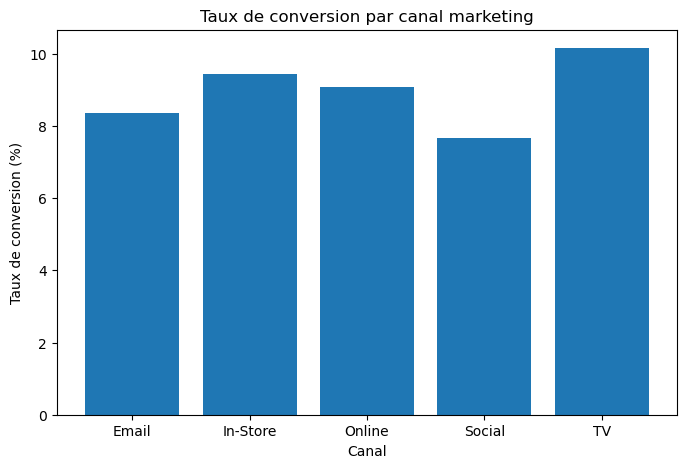

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_performance["channel"],
    channel_performance["conversion_rate"]
)

plt.xlabel("Canal")
plt.ylabel("Taux de conversion (%)")
plt.title("Taux de conversion par canal marketing")

plt.show()

### Comparer le CPA par canal  
Le CPA répond à la question : **Combien coûte en moyenne l’obtention d’une conversion ?**  
Plus le CPA est **faible**, mieux c'est.

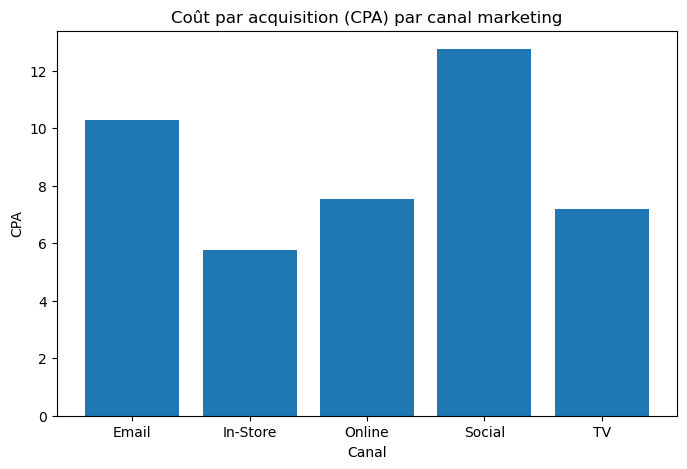

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_performance["channel"],
    channel_performance["cpa"]
)

plt.xlabel("Canal")
plt.ylabel("CPA")
plt.title("Coût par acquisition (CPA) par canal marketing")

plt.show()

Analysons maintenant les campagnes individuelles.  

Une campagne peut avoir beaucoup de conversions, mais dépenser énormément pour les obtenir.

In [17]:
#les plus performantes

best_campaigns = (
    marketing
    .sort_values("cpa", ascending=True)
    [["campaign_id", "channel", "budget", "clicks", "conversions",
      "conversion_rate", "cpc", "cpa"]]
)

best_campaigns.head(10)

,campaign_id,channel,budget,clicks,conversions,conversion_rate,cpc,cpa
74,75,In-Store,596.29,5327,634,11.901633,0.111937,0.940521
78,79,TV,972.58,11361,1019,8.969281,0.085607,0.954446
25,26,Email,1206.78,6442,948,14.715927,0.187330,1.272975
77,78,In-Store,728.16,7358,550,7.474857,0.098962,1.323927
68,69,In-Store,1834.43,7690,1107,14.395319,0.238547,1.657118
62,63,Online,590.30,2767,339,12.251536,0.213336,1.741298
13,14,Email,644.03,4229,335,7.921494,0.152289,1.922478
22,23,Online,492.14,1680,237,14.107143,0.292940,2.076540
4,5,Online,2882.14,10593,1365,12.885868,0.272080,2.111458
70,71,Online,896.33,3512,329,9.367882,0.255219,2.724407


In [16]:
#les moins performantes

worst_campaigns = (
    marketing
    .sort_values("cpa", ascending=False)
    [["campaign_id", "channel", "budget", "clicks", "conversions",
      "conversion_rate", "cpc", "cpa"]]
)

worst_campaigns.head(10)

,campaign_id,channel,budget,clicks,conversions,conversion_rate,cpc,cpa
72,73,Social,2916.29,371,15,4.043127,7.860620,194.419333
75,76,Social,2384.39,244,13,5.327869,9.772090,183.414615
21,22,Social,4303.83,560,28,5.000000,7.685411,153.708214
80,81,Online,3271.23,364,33,9.065934,8.986896,99.128182
53,54,Email,4085.49,1327,47,3.541824,3.078742,86.925319
18,19,Email,4089.80,1142,57,4.991243,3.581261,71.750877
88,89,TV,3319.41,348,50,14.367816,9.538534,66.388200
20,21,Email,2825.73,487,44,9.034908,5.802320,64.221136
1,2,In-Store,3853.39,968,66,6.818182,3.980775,58.384697
31,32,Email,2188.77,458,40,8.733624,4.778974,54.719250


Voyons les campagnes qui ont généré le plus de conversions.

In [18]:
top_conversions = (
    marketing
    .sort_values("conversions", ascending=False)
    [["campaign_id", "channel", "budget", "clicks", "conversions",
      "conversion_rate", "cpc", "cpa"]]
)

top_conversions.head(10)

,campaign_id,channel,budget,clicks,conversions,conversion_rate,cpc,cpa
4,5,Online,2882.14,10593,1365,12.885868,0.272080,2.111458
68,69,In-Store,1834.43,7690,1107,14.395319,0.238547,1.657118
52,53,In-Store,4218.23,9780,1067,10.910020,0.431312,3.953355
78,79,TV,972.58,11361,1019,8.969281,0.085607,0.954446
95,96,TV,4474.55,6623,981,14.812019,0.675608,4.561213
25,26,Email,1206.78,6442,948,14.715927,0.187330,1.272975
96,97,TV,4223.50,7636,871,11.406496,0.553104,4.849024
56,57,Social,3723.23,5626,697,12.388909,0.661790,5.341793
86,87,Online,3209.44,7190,681,9.471488,0.446376,4.712834
74,75,In-Store,596.29,5327,634,11.901633,0.111937,0.940521


**visualisation des 10 meilleurs campagnes selon le CPA**

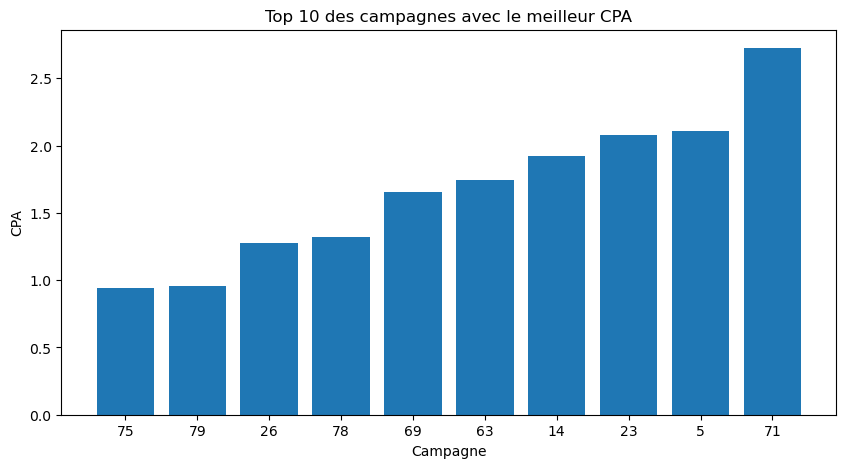

In [19]:
top_10_cpa = (
    marketing
    .sort_values("cpa", ascending=True)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_10_cpa["campaign_id"].astype(str),
    top_10_cpa["cpa"]
)

plt.xlabel("Campagne")
plt.ylabel("CPA")
plt.title("Top 10 des campagnes avec le meilleur CPA")

plt.show()

**Visualisation des 10 campagnes qui ont généré le plus de conversions.**

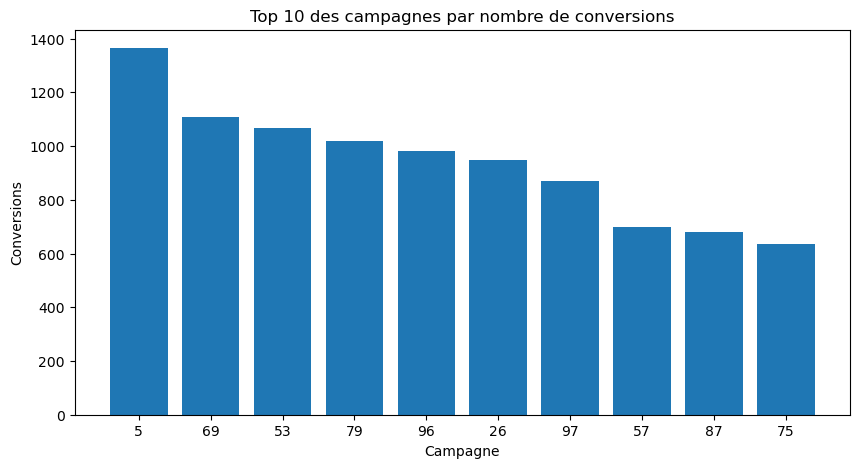

In [20]:
top_10_conversions = (
    marketing
    .sort_values("conversions", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_10_conversions["campaign_id"].astype(str),
    top_10_conversions["conversions"]
)

plt.xlabel("Campagne")
plt.ylabel("Conversions")
plt.title("Top 10 des campagnes par nombre de conversions")

plt.show()

**Canaux à privilégier**

**In-Store**  

CPA le plus faible : 5,76  
CPC le plus faible : 0,54  
Taux de conversion élevé : 9,44 %  
→ canal très efficace financièrement selon les coûts disponibles.  

**TV**  

meilleur taux de conversion : 10,16 %  
CPA raisonnable : 7,20  
→ canal performant pour générer des conversions.  

**Online**  

taux de conversion : 9,08 %  
CPA : 7,55  
→ performance équilibrée.  
Canaux à optimiser  

**Email**  

conversion : 8,35 %  
CPA : 10,28  
→ performances correctes mais coût d'acquisition relativement élevé.  

**Social**  

conversion : 7,67 %  
CPA : 12,76, le plus élevé  
CPC : 0,98, également le plus élevé  
→ canal nécessitant une optimisation importante.  

In [23]:
print("=== RECOMMANDATIONS MARKETING ===")
print()
print("1. Prioriser les canaux In-Store et TV pour leur efficacité.")
print("2. Maintenir Online comme canal performant et équilibré.")
print("3. Optimiser les campagnes Email pour réduire le CPA.")
print("4. Réévaluer les campagnes Social présentant un CPA élevé.")
print("5. Suivre le ROI financier lorsque les données de revenus seront disponibles.")

=== RECOMMANDATIONS MARKETING ===

1. Prioriser les canaux In-Store et TV pour leur efficacité.
2. Maintenir Online comme canal performant et équilibré.
3. Optimiser les campagnes Email pour réduire le CPA.
4. Réévaluer les campagnes Social présentant un CPA élevé.
5. Suivre le ROI financier lorsque les données de revenus seront disponibles.


## Conclusion que tu peux mettre dans le notebook

**L'analyse des campagnes marketing montre que les canaux In-Store, TV et Online présentent les performances les plus intéressantes. Le canal In-Store se distingue notamment par son faible CPA, tandis que la TV obtient le meilleur taux de conversion.  
À l'inverse, le canal Social présente un taux de conversion plus faible et un CPA plus élevé, ce qui suggère la nécessité d'une optimisation des campagnes. L'analyse des campagnes individuelles permet également d'identifier des campagnes particulièrement efficaces en termes de volume de conversions et de coût d'acquisition.  
Enfin, le ROI financier n'a pas pu être calculé en l'absence de données de revenus associées aux campagnes.**